In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import mlflow
import mlflow.sklearn
import pickle

In [2]:
df = pd.read_csv("../../data/crime_500k_cleaned.csv")

In [3]:
cat_columns = df.select_dtypes(include=["object"]).columns
num_columns = df.select_dtypes(include=["int64","float64"]).columns

In [4]:
df.columns

Index(['Primary Type', 'Arrest', 'Domestic', 'District', 'Community Area',
       'Year', 'Latitude', 'Longitude', 'Hour', 'Day', 'Day_of_Week', 'Month',
       'Is_Weekend', 'Crime_Severity_Score', 'Season'],
      dtype='object')

In [5]:
label_encoder = LabelEncoder()
for i in cat_columns:
    df[i] = label_encoder.fit_transform(df[i])

In [6]:
features = [
    'Primary Type',
    'Arrest',
    'Domestic',
    'Latitude',
    'Longitude',
    'Hour',
    'Month',
    'Crime_Severity_Score'
]
X = df[features]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
pickle.dump(scaler, open("../../models/PCA_scaler.pkl", "wb"))

In [9]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained:", pca.explained_variance_ratio_.sum())

Variance explained: 0.7862321706561045


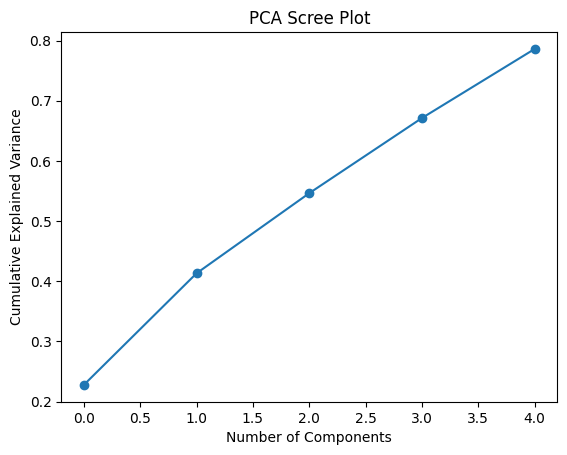

In [10]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.show()

In [13]:
importance = np.abs(pca.components_[0])
top_features = pd.Series(importance, index=X.columns).sort_values(ascending=False)
print("Top 5 Important Features:")
print(top_features.head(5))

Top 5 Important Features:
Crime_Severity_Score    0.557603
Primary Type            0.514513
Domestic                0.491216
Latitude                0.315804
Longitude               0.241628
dtype: float64


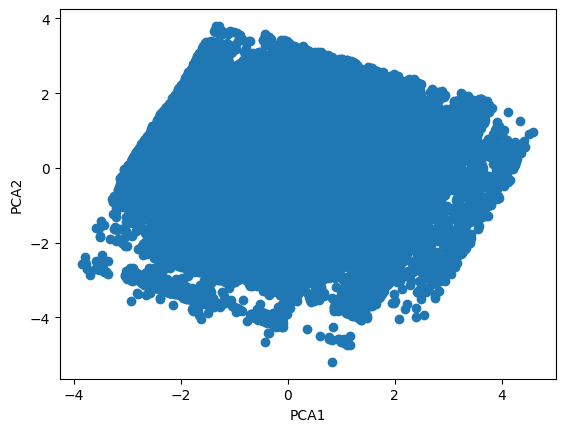

In [14]:
# PCA 1 and 2 in scatter plot
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [21]:
sample_data = X_pca[:5000]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

X_tsne = tsne.fit_transform(sample_data)

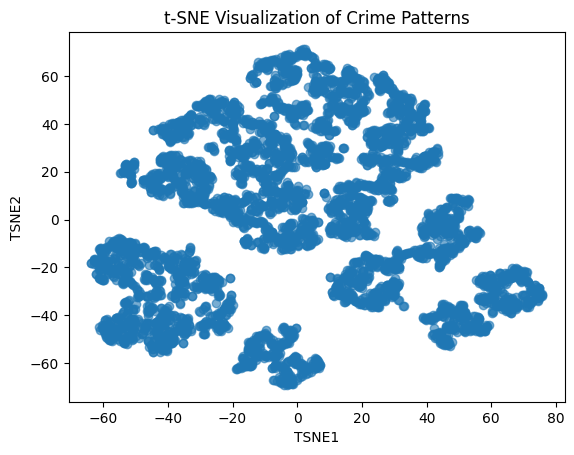

In [22]:
plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.6)

plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.title("t-SNE Visualization of Crime Patterns")
plt.show()

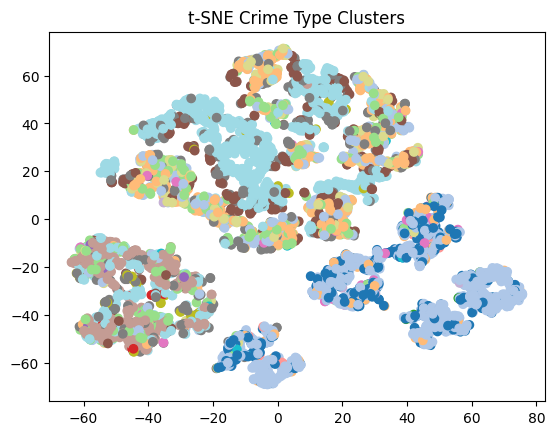

In [ ]:
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=X['Primary Type'][:5000],
    cmap='tab20'
)

plt.title("t-SNE Crime Type Clusters")
plt.show()

In [24]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Dimensionality reduction")
with mlflow.start_run(run_name="PCA"):
    mlflow.log_param("n_components", 5)
    mlflow.log_metric("variance", sum(pca.explained_variance_ratio_))
    mlflow.sklearn.log_model(pca, "PCA")

2026/03/09 16:34:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 16:34:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/09 16:34:06 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


🏃 View run PCA at: http://127.0.0.1:5000/#/experiments/3/runs/3d6450d3dcbc4a60b59f08417bf0a402
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [25]:
with open("../../models/pca.pkl", "wb") as f:
    pickle.dump(pca, f)